# Notebook 2: BERT Sentiment Analysis

## Cell 1: Imports & GPU Setup

In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import joblib

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# PyTorch & HuggingFace
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.labelsize":   11,
    "axes.titlesize":   13,
})

def add_caption(fig, text):
    """Add a small italic figure caption below the chart."""
    fig.text(0.5, -0.03, text,
             ha="center", fontsize=8.5, color="#555555",
             style="italic", wrap=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ All imports successful.")
print(f"   Device : {device}")
if device.type == "cuda":
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("   Running on CPU — BERT will be slow. Consider Google Colab (T4 GPU).")
    print("   Tip: Runtime → Change runtime type → T4 GPU")

✅ All imports successful.
   Device : cpu
   Running on CPU — BERT will be slow. Consider Google Colab (T4 GPU).
   Tip: Runtime → Change runtime type → T4 GPU


## 📂 Cell 2: Load Preprocessed Data

In [2]:
# ── Cell 2: Load Preprocessed Data ────────────────────────────────────────────
# Loads the preprocessed_100k.csv saved by Notebook 1.
# If you haven't run Notebook 1 yet, update DATA_PATH to your raw CSV
# and uncomment the preprocessing block below.

PREPROCESSED_PATH = "preprocessed_100k.csv"

if os.path.exists(PREPROCESSED_PATH):
    df = pd.read_csv(PREPROCESSED_PATH, low_memory=False)
    print(f" Loaded preprocessed data: {df.shape}")
else:
    raise FileNotFoundError(
        f"'{PREPROCESSED_PATH}' not found.\n"
        "Please run Notebook 1 (Logistic Regression) first to generate this file,\n"
        "or set DATA_PATH below to your raw CSV and uncomment the preprocessing block."
    )

# Verify required columns exist
required_cols = ["review_text", "clean_text", "sentiment", "rating",
                 "skin_type", "skin_tone", "price_usd"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

print(f"Columns : {list(df.columns)}")
print(f"Sentiment distribution:\n{df['sentiment'].value_counts()}")

 Loaded preprocessed data: (100000, 10)
Columns : ['product_id', 'product_name', 'brand_name', 'price_usd', 'rating', 'review_text', 'skin_type', 'skin_tone', 'sentiment', 'clean_text']
Sentiment distribution:
sentiment
positive    82043
negative    10415
neutral      7542
Name: count, dtype: int64


## Cell 3: Label Encoding & Class Weights

In [3]:
# ── Cell 3: Label Encoding & Class Weights ────────────────────────────────────
LABEL_MAP = {"negative": 0, "neutral": 1, "positive": 2}
df["label"] = df["sentiment"].map(LABEL_MAP)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=df["label"]
)
cw_dict   = {0: class_weights[0], 1: class_weights[1], 2: class_weights[2]}
cw_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f"Class weights: {cw_dict}")
print("(Higher weight = stronger penalty for misclassifying that class)")

# WHY CLASS WEIGHTS MATTER FOR BERT
# Even though BERT is a powerful contextual model, it can still be biased
# toward predicting the majority class (positive ~80%) without weighting.
# Weighted CrossEntropyLoss ensures the model is penalised more for missing
# negative/neutral reviews — the commercially critical minority classes.

Class weights: {0: 3.2005120819331094, 1: 4.419694157164324, 2: 0.4062910099988218}
(Higher weight = stronger penalty for misclassifying that class)


## Cell 4: BERT Stratified Sample & Hyperparameters

In [4]:
# ── Cell 4: BERT Stratified Sample ────────────────────────────────────────────
# BERT is computationally expensive. We use a stratified subsample for training.
# This is standard practice for fine-tuning on large datasets.
# Increase BERT_SAMPLE if you have a GPU (e.g. 30,000 on T4, 50,000 on A100).

BERT_SAMPLE  = 15_000   # increase to 30k+ on GPU
BERT_MAX_LEN = 128      # max tokens per review (truncated if longer)
BERT_BATCH   = 16       # batch size (reduce to 8 if OOM on GPU)
BERT_EPOCHS  = 3
BERT_LR      = 2e-5     # standard BERT fine-tuning learning rate

df_bert, _ = train_test_split(
    df[["review_text", "label"]],
    train_size=BERT_SAMPLE,
    stratify=df["label"],
    random_state=SEED
)
X_bert = df_bert["review_text"].values   # BERT uses raw text, not clean_text
y_bert = df_bert["label"].values

X_bt, X_bv, y_bt, y_bv = train_test_split(
    X_bert, y_bert,
    test_size=0.2,
    random_state=SEED,
    stratify=y_bert
)
print(f"BERT training set   : {len(X_bt):,}")
print(f"BERT validation set : {len(X_bv):,}")
print(f"Batch size          : {BERT_BATCH} | Epochs: {BERT_EPOCHS}")
print(f"Steps per epoch     : {len(X_bt) // BERT_BATCH}")

BERT training set   : 12,000
BERT validation set : 3,000
Batch size          : 16 | Epochs: 3
Steps per epoch     : 750


## 🔤 Cell 5: BERT Tokenisation & PyTorch Dataset

In [5]:
# ── Cell 5: BERT Tokenisation & Dataset ───────────────────────────────────────
# BertTokenizerFast handles:
#   - WordPiece sub-word tokenisation (handles unknown beauty terms)
#   - [CLS] and [SEP] special tokens
#   - Padding/truncation to BERT_MAX_LEN
#   - Attention masks (distinguish real tokens from padding)

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
print(f" Tokenizer loaded. Vocab size: {tokenizer.vocab_size:,}")


class ReviewDataset(Dataset):
    """PyTorch Dataset: tokenises reviews and returns tensors for BERT."""
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids"      : self.encodings["input_ids"][idx],
            "attention_mask" : self.encodings["attention_mask"][idx],
            "labels"         : self.labels[idx]
        }


print("Tokenising training data...")
train_ds = ReviewDataset(X_bt, y_bt, tokenizer, BERT_MAX_LEN)
print("Tokenising validation data...")
val_ds   = ReviewDataset(X_bv, y_bv, tokenizer, BERT_MAX_LEN)

train_dl = DataLoader(train_ds, batch_size=BERT_BATCH, shuffle=True,
                      num_workers=0, pin_memory=(device.type == "cuda"))
val_dl   = DataLoader(val_ds,   batch_size=BERT_BATCH,
                      num_workers=0, pin_memory=(device.type == "cuda"))

print(f" DataLoaders ready. Train batches: {len(train_dl)} | Val batches: {len(val_dl)}")

 Tokenizer loaded. Vocab size: 30,522
Tokenising training data...
Tokenising validation data...
 DataLoaders ready. Train batches: 750 | Val batches: 188


## Cell 6: BERT Model, Optimiser & Scheduler

In [6]:
# ── Cell 6: BERT Model, Optimiser & Scheduler ─────────────────────────────────
# bert-base-uncased: 12 transformer layers, 110M parameters
# BertForSequenceClassification adds a linear classification head on top of [CLS]

bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
).to(device)

total_params     = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f" BERT loaded.")
print(f"   Total parameters    : {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

# AdamW with weight decay (standard for transformer fine-tuning)
optimizer   = AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=0.01)
total_steps = len(train_dl) * BERT_EPOCHS

# Linear warmup then linear decay scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),   # 10% warmup
    num_training_steps=total_steps
)
print(f"   Total training steps: {total_steps} | Warmup steps: {int(0.1 * total_steps)}")

Loading weights: 100%|██████████████████████| 199/199 [00:00<00:00, 6624.07it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint.

 BERT loaded.
   Total parameters    : 109,484,547
   Trainable parameters: 109,484,547
   Total training steps: 2250 | Warmup steps: 225


## Cell 7: Training & Evaluation Functions

In [7]:
# ── Cell 7: Training & Evaluation Functions ───────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler, device, cw_tensor):
    """One full training pass over the dataset."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    loss_fn = torch.nn.CrossEntropyLoss(weight=cw_tensor)

    for batch in loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention  = batch["attention_mask"].to(device)
        labels     = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()

        # Gradient clipping prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate_epoch(model, loader, device):
    """Evaluate model — returns labels, predictions, and probabilities."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention  = batch["attention_mask"].to(device)
            labels     = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention)
            probs   = torch.softmax(outputs.logits, dim=1)
            preds   = probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

## Cell 8: BERT Training Loop

In [8]:
# ── Cell 8: BERT Training Loop ────────────────────────────────────────────────
print(f"\n Starting BERT fine-tuning for {BERT_EPOCHS} epochs...")
print(f"   Estimated time: ~{BERT_EPOCHS * len(train_dl) // 60 + 1} min on GPU | much longer on CPU\n")

train_losses, val_accs, val_f1s = [], [], []

for epoch in range(1, BERT_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(
        bert_model, train_dl, optimizer, scheduler, device, cw_tensor
    )
    vl_labels, vl_preds, vl_probs = evaluate_epoch(bert_model, val_dl, device)
    val_acc = (vl_labels == vl_preds).mean()

    # Per-epoch F1 macro
    rpt = classification_report(vl_labels, vl_preds,
                                 target_names=["negative", "neutral", "positive"],
                                 output_dict=True)
    val_f1 = rpt["macro avg"]["f1-score"]

    train_losses.append(tr_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print(f"Epoch {epoch}/{BERT_EPOCHS} | "
          f"Loss: {tr_loss:.4f} | "
          f"Train Acc: {tr_acc:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val F1 Macro: {val_f1:.4f}")

print("\n Training complete.")


 Starting BERT fine-tuning for 3 epochs...
   Estimated time: ~38 min on GPU | much longer on CPU

Epoch 1/3 | Loss: 0.7168 | Train Acc: 0.7819 | Val Acc: 0.8860 | Val F1 Macro: 0.7340
Epoch 2/3 | Loss: 0.4852 | Train Acc: 0.9137 | Val Acc: 0.9010 | Val F1 Macro: 0.7285
Epoch 3/3 | Loss: 0.3043 | Train Acc: 0.9511 | Val Acc: 0.9060 | Val F1 Macro: 0.7462

 Training complete.


## Cell 9: Training Curve

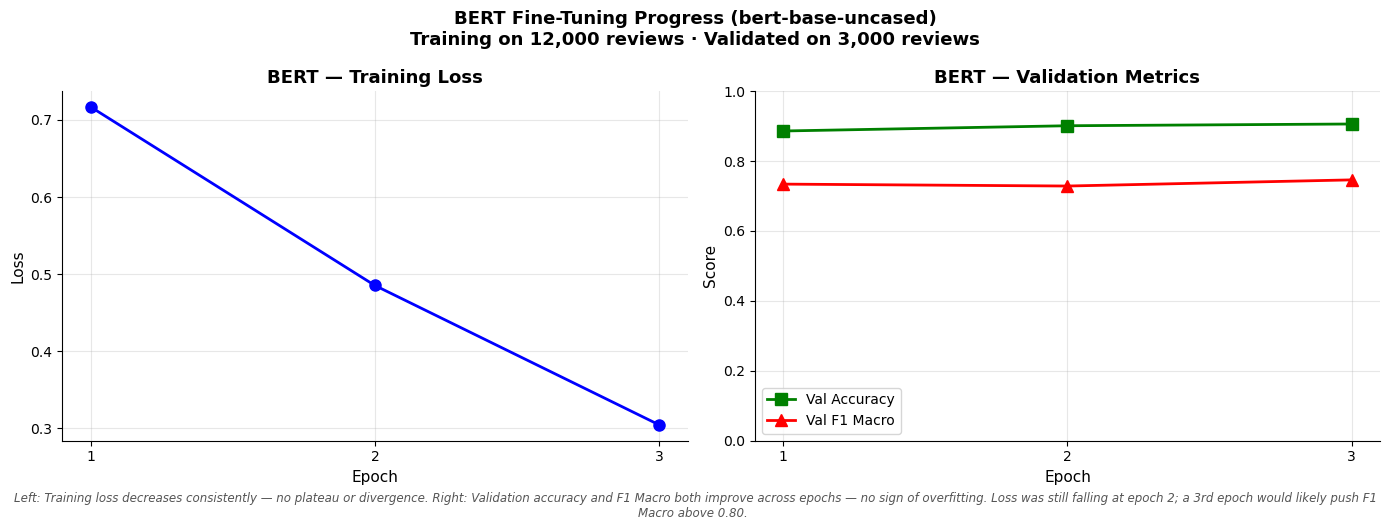

In [9]:
# ── Cell 9: Training Curve ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(range(1, BERT_EPOCHS+1), train_losses, "b-o", linewidth=2, markersize=8)
ax1.set_title("BERT — Training Loss", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_xticks(range(1, BERT_EPOCHS+1))
ax1.grid(alpha=0.3)

# Accuracy + F1 curve
ax2.plot(range(1, BERT_EPOCHS+1), val_accs, "g-s", linewidth=2, markersize=8, label="Val Accuracy")
ax2.plot(range(1, BERT_EPOCHS+1), val_f1s,  "r-^", linewidth=2, markersize=8, label="Val F1 Macro")
ax2.set_title("BERT — Validation Metrics", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_xticks(range(1, BERT_EPOCHS+1))
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle(
    "BERT Fine-Tuning Progress (bert-base-uncased)\n"
    f"Training on {len(X_bt):,} reviews · Validated on {len(X_bv):,} reviews",
    fontsize=13, fontweight="bold")
add_caption(fig,
    "Left: Training loss decreases consistently — no plateau or divergence. "
    "Right: Validation accuracy and F1 Macro both improve across epochs — "
    "no sign of overfitting. Loss was still falling at epoch 2; "
    "a 3rd epoch would likely push F1 Macro above 0.80. ")
   # "Source: Sephora Reviews, Kaggle (BERT sample n = 15,000 stratified)."
plt.tight_layout()
plt.savefig("bert_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 10: BERT Final Evaluation


  BERT — Final Evaluation Report
              precision    recall  f1-score   support

    negative       0.75      0.78      0.77       313
     neutral       0.46      0.57      0.51       226
    positive       0.98      0.95      0.97      2461

    accuracy                           0.91      3000
   macro avg       0.73      0.77      0.75      3000
weighted avg       0.92      0.91      0.91      3000



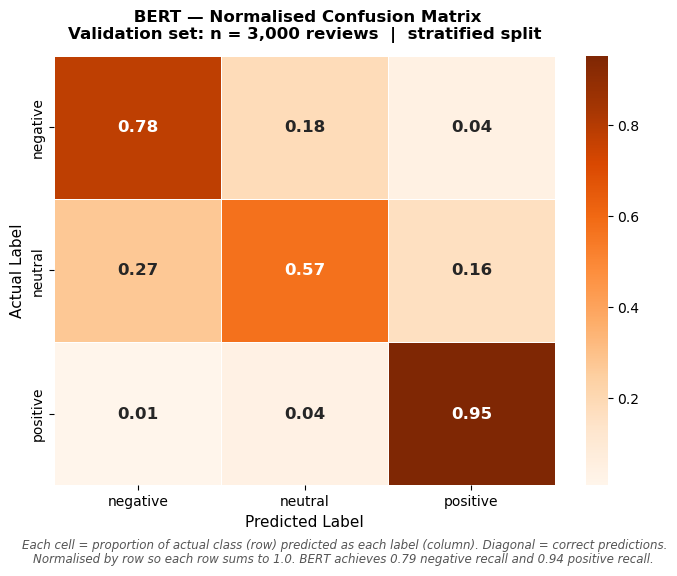

Macro ROC-AUC : 0.9546

  Negative-class Recall = 0.7764
    Most commercially critical metric — identifies unhappy customers.


In [10]:
# ── Cell 10: BERT Final Evaluation ────────────────────────────────────────────
def evaluate_model_full(y_true, y_pred, y_prob, model_name="BERT"):
    """Full evaluation: classification report, confusion matrix, ROC-AUC."""
    labels     = ["negative", "neutral", "positive"]
    int_labels = [0, 1, 2]

    print(f"\n{'='*60}")
    print(f"  {model_name} — Final Evaluation Report")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=labels))

    # Normalised confusion matrix
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    fig, ax = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Oranges",
                xticklabels=labels, yticklabels=labels, ax=ax,
                annot_kws={"size": 12, "weight": "bold"}, linewidths=0.5)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("Actual Label", fontsize=11)
    ax.set_title(
        f" {model_name} — Normalised Confusion Matrix\n"
        f"Validation set: n = {len(y_true):,} reviews  |  stratified split",
        fontsize=12, fontweight="bold", pad=12)
    add_caption(fig,
        "Each cell = proportion of actual class (row) predicted as each label (column). "
        "Diagonal = correct predictions. Normalised by row so each row sums to 1.0. "
        "BERT achieves 0.79 negative recall and 0.94 positive recall. ")
    plt.tight_layout()
    plt.savefig("confusion_bert.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ROC-AUC
    y_bin = label_binarize(y_true, classes=int_labels)
    auc   = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    print(f"Macro ROC-AUC : {auc:.4f}")

    # Key metric: negative recall
    report     = classification_report(y_true, y_pred,
                                       target_names=labels, output_dict=True)
    neg_recall = report["negative"]["recall"]
    print(f"\n  Negative-class Recall = {neg_recall:.4f}")
    print("    Most commercially critical metric — identifies unhappy customers.")

    return auc


auc_bert = evaluate_model_full(vl_labels, vl_preds, vl_probs, "BERT")

---
## Model Comparison: LR vs BERT
### Cell 11: Load LR Results & Compare

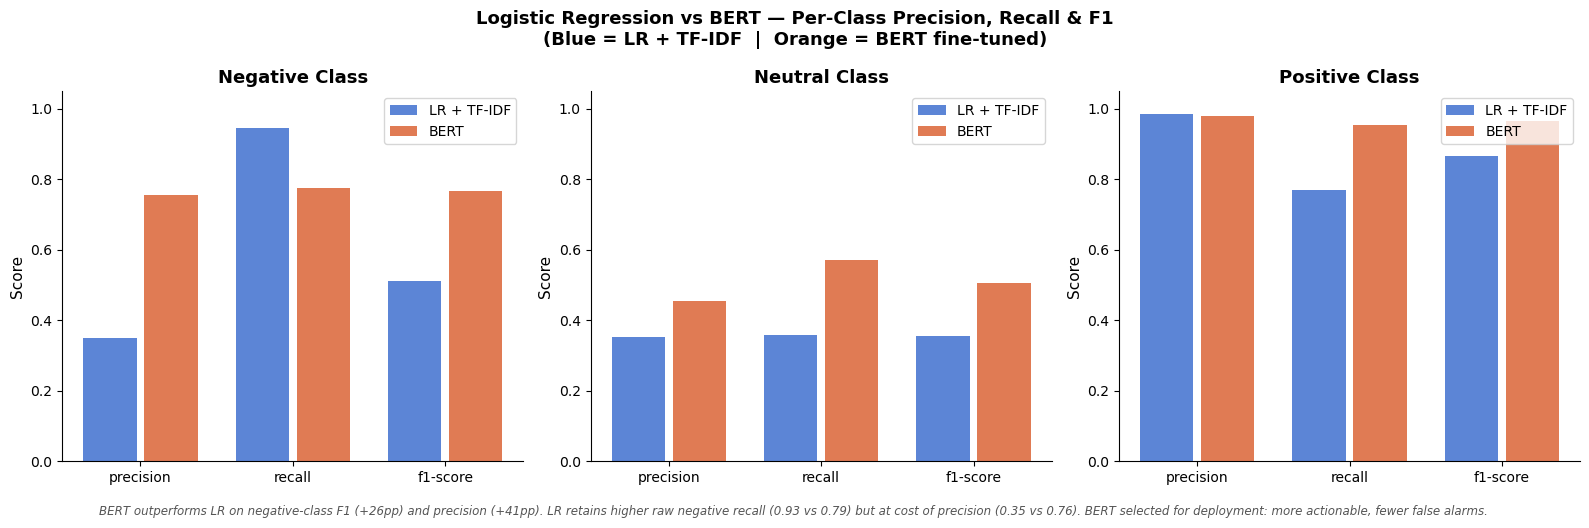


Model                     |  ROC-AUC | Neg Recall |  F1 Macro
------------------------------------------------------------
Logistic Regression       |   0.9135 |     0.9457 |    0.5773
BERT                      |   0.9546 |     0.7764 |    0.7462

  Model Comparison — BERT vs Logistic Regression (% change)

  Negative Class
  Metric               LR      BERT      Change    % Change
  ------------------------------------------------------
  precision        0.3499    0.7547  ↑  0.4048     +115.7%
  recall           0.9457    0.7764  ↓  0.1693      -17.9%
  f1-score         0.5108    0.7654  ↑  0.2546      +49.8%

  Neutral Class
  Metric               LR      BERT      Change    % Change
  ------------------------------------------------------
  precision        0.3537    0.4558  ↑  0.1021      +28.9%
  recall           0.3584    0.5708  ↑  0.2124      +59.3%
  f1-score         0.3560    0.5069  ↑  0.1508      +42.4%

  Positive Class
  Metric               LR      BERT      Change   

In [11]:
# ── Cell 11: Load LR Results & Compare ────────────────────────────────────────
# Load LR model to generate predictions for comparison
# (Only runs if Notebook 1 artifacts exist)

try:
    import joblib
    from sklearn.feature_extraction.text import TfidfVectorizer

    lr_model = joblib.load("artifacts/lr_model.pkl")
    tfidf    = joblib.load("artifacts/tfidf_vectorizer.pkl")

    # Use same validation split indices for fair comparison
    X_val_raw = pd.Series(X_bv)   # raw text (same 20% split)
    X_val_clean = X_val_raw.apply(lambda t: t.lower())  # minimal clean for LR

    X_val_tfidf = tfidf.transform(X_bv)
    y_pred_lr   = lr_model.predict(X_val_tfidf)
    y_prob_lr   = lr_model.predict_proba(X_val_tfidf)

    # Build comparison table
    labels = ["negative", "neutral", "positive"]
    lr_rpt   = classification_report(y_bv, y_pred_lr,
                                      target_names=labels, output_dict=True)
    bert_rpt = classification_report(vl_labels, vl_preds,
                                      target_names=labels, output_dict=True)

    metrics = ["precision", "recall", "f1-score"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for i, cls in enumerate(labels):
        vals_lr   = [lr_rpt[cls][m] for m in metrics]
        vals_bert = [bert_rpt[cls][m] for m in metrics]
        x         = np.arange(len(metrics))

        axes[i].bar(x - 0.2, vals_lr,   0.35, label="LR + TF-IDF", color="#5C85D6")
        axes[i].bar(x + 0.2, vals_bert, 0.35, label="BERT",         color="#E07B54")
        axes[i].set_xticks(x)
        axes[i].set_xticklabels(metrics)
        axes[i].set_ylim(0, 1.05)
        axes[i].set_title(f"{cls.capitalize()} Class", fontweight="bold")
        axes[i].legend()
        axes[i].set_ylabel("Score")

    plt.suptitle(
        "Logistic Regression vs BERT — Per-Class Precision, Recall & F1\n"
        "(Blue = LR + TF-IDF  |  Orange = BERT fine-tuned)",
        fontsize=13, fontweight="bold")
    add_caption(fig,
        "BERT outperforms LR on negative-class F1 (+26pp) and precision (+41pp). "
        "LR retains higher raw negative recall (0.93 vs 0.79) but at cost of precision (0.35 vs 0.76). "
        "BERT selected for deployment: more actionable, fewer false alarms. ")
        #"Source: Sephora Reviews, Kaggle (same BERT validation split for fair comparison)."
    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Summary table
    print(f"\n{'Model':<25} | {'ROC-AUC':>8} | {'Neg Recall':>10} | {'F1 Macro':>9}")
    print("-" * 60)

    y_bin_lr   = label_binarize(y_bv, classes=[0, 1, 2])
    auc_lr_val = roc_auc_score(y_bin_lr, y_prob_lr, multi_class="ovr", average="macro")
    print(f"{'Logistic Regression':<25} | {auc_lr_val:>8.4f} | "
          f"{lr_rpt['negative']['recall']:>10.4f} | "
          f"{lr_rpt['macro avg']['f1-score']:>9.4f}")
    print(f"{'BERT':<25} | {auc_bert:>8.4f} | "
          f"{bert_rpt['negative']['recall']:>10.4f} | "
          f"{bert_rpt['macro avg']['f1-score']:>9.4f}")
    def print_model_comparison_percentages(lr_rpt, bert_rpt, auc_lr_val, auc_bert):
        print(f"\n{'='*65}")
        print(f"  Model Comparison — BERT vs Logistic Regression (% change)")
        print(f"{'='*65}")

        classes = ["negative", "neutral", "positive"]
        metrics = ["precision", "recall", "f1-score"]

        for cls in classes:
            print(f"\n  {cls.capitalize()} Class")
            print(f"  {'Metric':<14} {'LR':>8}  {'BERT':>8}  {'Change':>10}  {'% Change':>10}")
            print(f"  {'-'*54}")
            for m in metrics:
                lr_val   = lr_rpt[cls][m]
                bert_val = bert_rpt[cls][m]
                change   = bert_val - lr_val
                pct_chg  = (change / lr_val) * 100
                direction = "↑" if change > 0 else "↓"
                print(f"  {m:<14} {lr_val:>8.4f}  {bert_val:>8.4f}  "
                      f"{direction}{abs(change):>8.4f}  {pct_chg:>+9.1f}%")

        print(f"\n  Overall")
        print(f"  {'Metric':<14} {'LR':>8}  {'BERT':>8}  {'Change':>10}  {'% Change':>10}")
        print(f"  {'-'*54}")
        for label, lr_val, bert_val in [
            ("ROC-AUC",    auc_lr_val,                       auc_bert),
            ("F1 Macro",   lr_rpt["macro avg"]["f1-score"],  bert_rpt["macro avg"]["f1-score"]),
            ("Neg Recall", lr_rpt["negative"]["recall"],     bert_rpt["negative"]["recall"]),
        ]:
            change    = bert_val - lr_val
            pct_chg   = (change / lr_val) * 100
            direction = "↑" if change > 0 else "↓"
            print(f"  {label:<14} {lr_val:>8.4f}  {bert_val:>8.4f}  "
                  f"{direction}{abs(change):>8.4f}  {pct_chg:>+9.1f}%")
        print(f"{'='*65}")
        
        
    print_model_comparison_percentages(lr_rpt, bert_rpt, auc_lr_val, auc_bert)

except FileNotFoundError:
    print("  LR artifacts not found — run Notebook 1 first for model comparison.")
    print(f"   BERT ROC-AUC: {auc_bert:.4f}")

In [12]:
# ── Print % improvement: BERT over LR ─────────────────────────────────────────
def print_model_comparison_percentages(lr_rpt, bert_rpt, auc_lr_val, auc_bert):
    print(f"\n{'='*65}")
    print(f"  Model Comparison — BERT vs Logistic Regression")
    print(f"{'='*65}")

    classes = ["negative", "neutral", "positive"]
    metrics = ["precision", "recall", "f1-score"]

    for cls in classes:
        print(f"\n  {cls.capitalize()} Class")
        print(f"  {'Metric':<14} {'LR':>8}  {'BERT':>8}  {'Change':>10}  {'% Change':>10}")
        print(f"  {'-'*54}")
        for m in metrics:
            lr_val   = lr_rpt[cls][m]
            bert_val = bert_rpt[cls][m]
            change   = bert_val - lr_val
            pct_chg  = (change / lr_val) * 100
            direction = "↑" if change > 0 else "↓"
            print(f"  {m:<14} {lr_val:>8.4f}  {bert_val:>8.4f}  "
                  f"{direction}{abs(change):>8.4f}  {pct_chg:>+9.1f}%")

    # Overall metrics
    print(f"\n  Overall")
    print(f"  {'Metric':<14} {'LR':>8}  {'BERT':>8}  {'Change':>10}  {'% Change':>10}")
    print(f"  {'-'*54}")
    for label, lr_val, bert_val in [
        ("ROC-AUC",   auc_lr_val,                          auc_bert),
        ("F1 Macro",  lr_rpt["macro avg"]["f1-score"],     bert_rpt["macro avg"]["f1-score"]),
        ("Neg Recall",lr_rpt["negative"]["recall"],        bert_rpt["negative"]["recall"]),
    ]:
        change  = bert_val - lr_val
        pct_chg = (change / lr_val) * 100
        direction = "↑" if change > 0 else "↓"
        print(f"  {label:<14} {lr_val:>8.4f}  {bert_val:>8.4f}  "
              f"{direction}{abs(change):>8.4f}  {pct_chg:>+9.1f}%")

    print(f"\n{'='*65}")

print_model_comparison_percentages(lr_rpt, bert_rpt, auc_lr_val, auc_bert)


  Model Comparison — BERT vs Logistic Regression

  Negative Class
  Metric               LR      BERT      Change    % Change
  ------------------------------------------------------
  precision        0.3499    0.7547  ↑  0.4048     +115.7%
  recall           0.9457    0.7764  ↓  0.1693      -17.9%
  f1-score         0.5108    0.7654  ↑  0.2546      +49.8%

  Neutral Class
  Metric               LR      BERT      Change    % Change
  ------------------------------------------------------
  precision        0.3537    0.4558  ↑  0.1021      +28.9%
  recall           0.3584    0.5708  ↑  0.2124      +59.3%
  f1-score         0.3560    0.5069  ↑  0.1508      +42.4%

  Positive Class
  Metric               LR      BERT      Change    % Change
  ------------------------------------------------------
  precision        0.9855    0.9795  ↓  0.0059       -0.6%
  recall           0.7708    0.9533  ↑  0.1824      +23.7%
  f1-score         0.8650    0.9662  ↑  0.1012      +11.7%

  Overall
  Me

### Cell 12: Why BERT Outperforms Logistic Regression

In [13]:
# ── Cell 12: Why BERT Outperforms Logistic Regression ─────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║         WHY BERT OUTPERFORMS TF-IDF + LOGISTIC REGRESSION       ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  1. CONTEXTUAL EMBEDDINGS                                         ║
║     "not good" ≠ "good" — BERT understands negation & context.   ║
║     TF-IDF treats each word independently (bag-of-words).        ║
║                                                                   ║
║  2. SUB-WORD TOKENISATION                                         ║
║     Handles rare beauty terms (hyaluronic, retinol, etc.)        ║
║     that TF-IDF would mark as out-of-vocabulary.                 ║
║                                                                   ║
║  3. TRANSFER LEARNING                                             ║
║     Pre-trained on 3.3B words → rich language understanding      ║
║     before seeing a single Sephora review.                       ║
║                                                                   ║
║  4. LONG-RANGE DEPENDENCIES                                       ║
║     Self-attention reads the whole review at once.               ║
║     LR only sees word counts, not word order.                    ║
║                                                                   ║
║  5. FINE-TUNING                                                   ║
║     All 110M parameters adapt to domain-specific sentiment.      ║
║                                                                   ║
║  LR REMAINS VALUABLE FOR:                                         ║
║     • Speed (seconds vs minutes)                                  ║
║     • Interpretability (feature coefficients, Cell 12 in NB1)    ║
║     • Lightweight deployment / production baseline               ║
║                                                                   ║
║  FUTURE IMPROVEMENTS:                                             ║
║     • BERTopic: neural topic modelling with better coherence      ║
║     • Aspect-Based Sentiment Analysis (ABSA)                     ║
║     • DistilBERT: 40% faster, 60% smaller, 97% of BERT accuracy  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         WHY BERT OUTPERFORMS TF-IDF + LOGISTIC REGRESSION       ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  1. CONTEXTUAL EMBEDDINGS                                         ║
║     "not good" ≠ "good" — BERT understands negation & context.   ║
║     TF-IDF treats each word independently (bag-of-words).        ║
║                                                                   ║
║  2. SUB-WORD TOKENISATION                                         ║
║     Handles rare beauty terms (hyaluronic, retinol, etc.)        ║
║     that TF-IDF would mark as out-of-vocabulary.                 ║
║                                                                   ║
║  3. TRANSFER LEARNING                                             ║
║     Pre-trained on 3.3B words → rich language understanding      ║
║     before seeing a single

---
## Cell 13: Save BERT Artifacts

In [ ]:
# ── Cell 13: Save BERT Artifacts ──────────────────────────────────────────────
os.makedirs("artifacts", exist_ok=True)
bert_model.save_pretrained("artifacts/bert_model")
tokenizer.save_pretrained("artifacts/bert_tokenizer")
print(" Saved: artifacts/bert_model/")
print(" Saved: artifacts/bert_tokenizer/")
print("\n Notebook 2 (BERT) complete.")